In [1]:
%load_ext autoreload
%autoreload 2

In [27]:
import squidpy as sq
import scanpy as sc
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

In [3]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor="white")

/tmp/1439146.tinyfat/ipykernel_643165/2545731980.py:2: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=80, facecolor="white")


In [4]:
adata = sq.datasets.visium_hne_adata()
adata

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

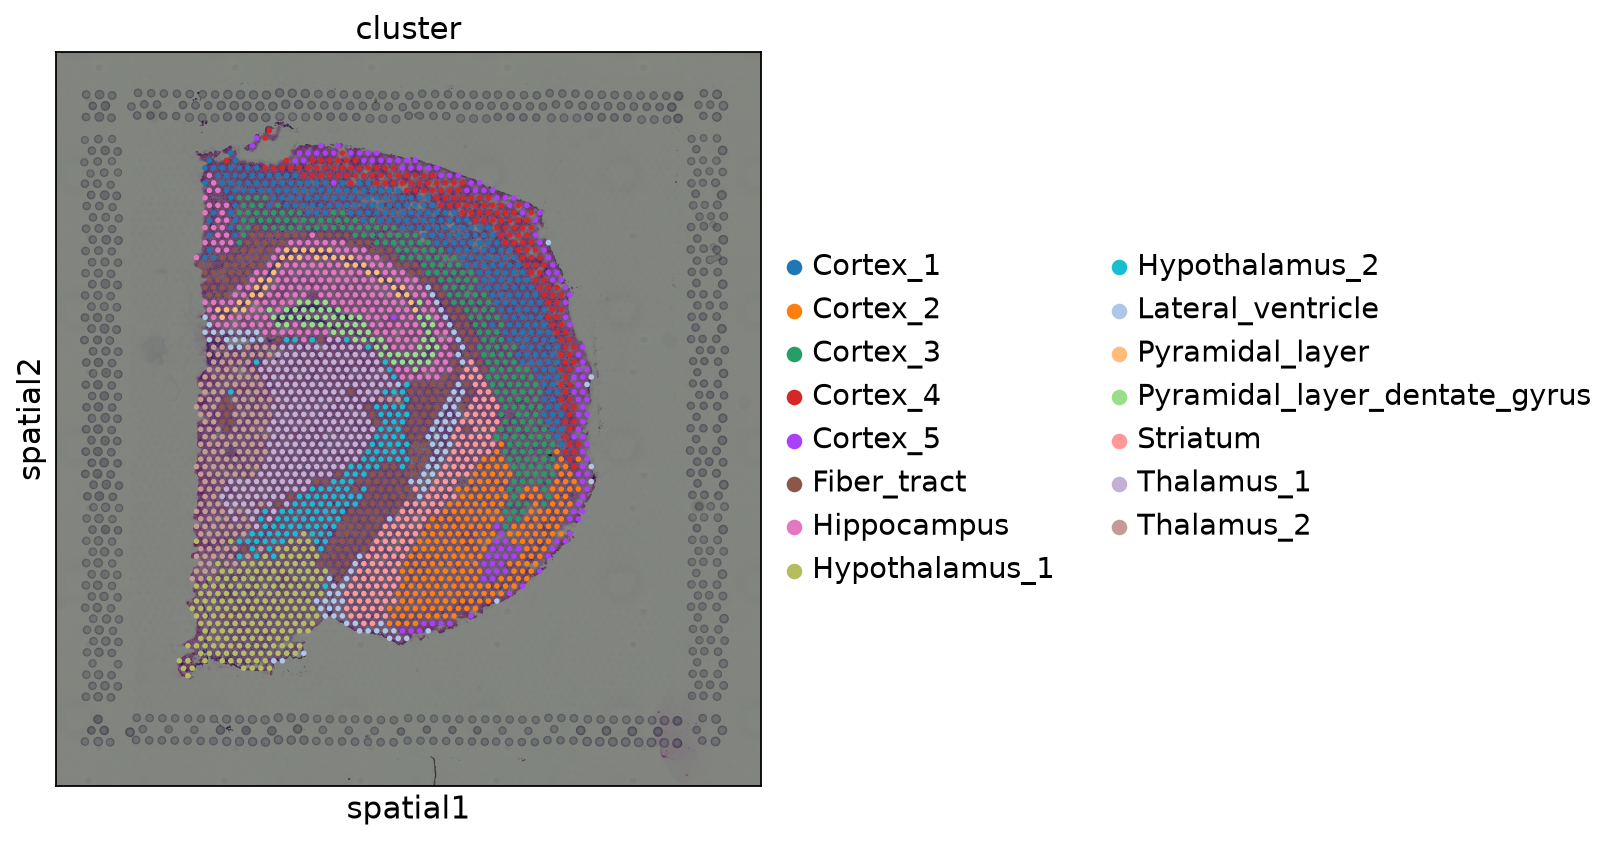

In [5]:
sq.pl.spatial_scatter(adata, color="cluster", figsize=(10, 10))

In [6]:
adata

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

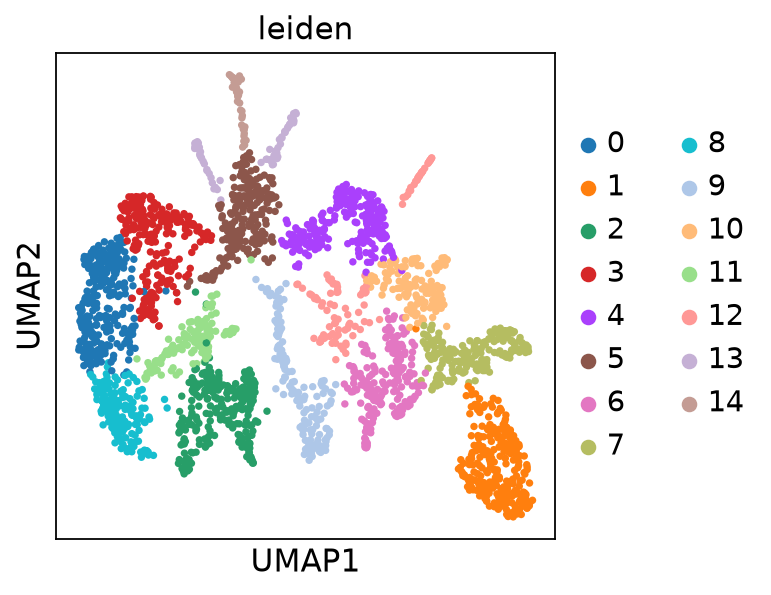

In [7]:
sc.pl.umap(adata, color="leiden")

In [8]:
sc.pp.neighbors(adata)
nn_graph_genes = adata.obsp["connectivities"]
# spatial proximity graph
sq.gr.spatial_neighbors_knn(adata)
nn_graph_space = adata.obsp["spatial_connectivities"]

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:12)
INFO     Creating graph using `None` transform and `1` libraries.                                                  
Adding `adata.obsp['spatial_connectivities']`
       `adata.obsp['spatial_distances']`
       `adata.uns['spatial_neighbors']`


In [9]:
G = nx.from_scipy_sparse_array(adata.obsp['spatial_connectivities'])

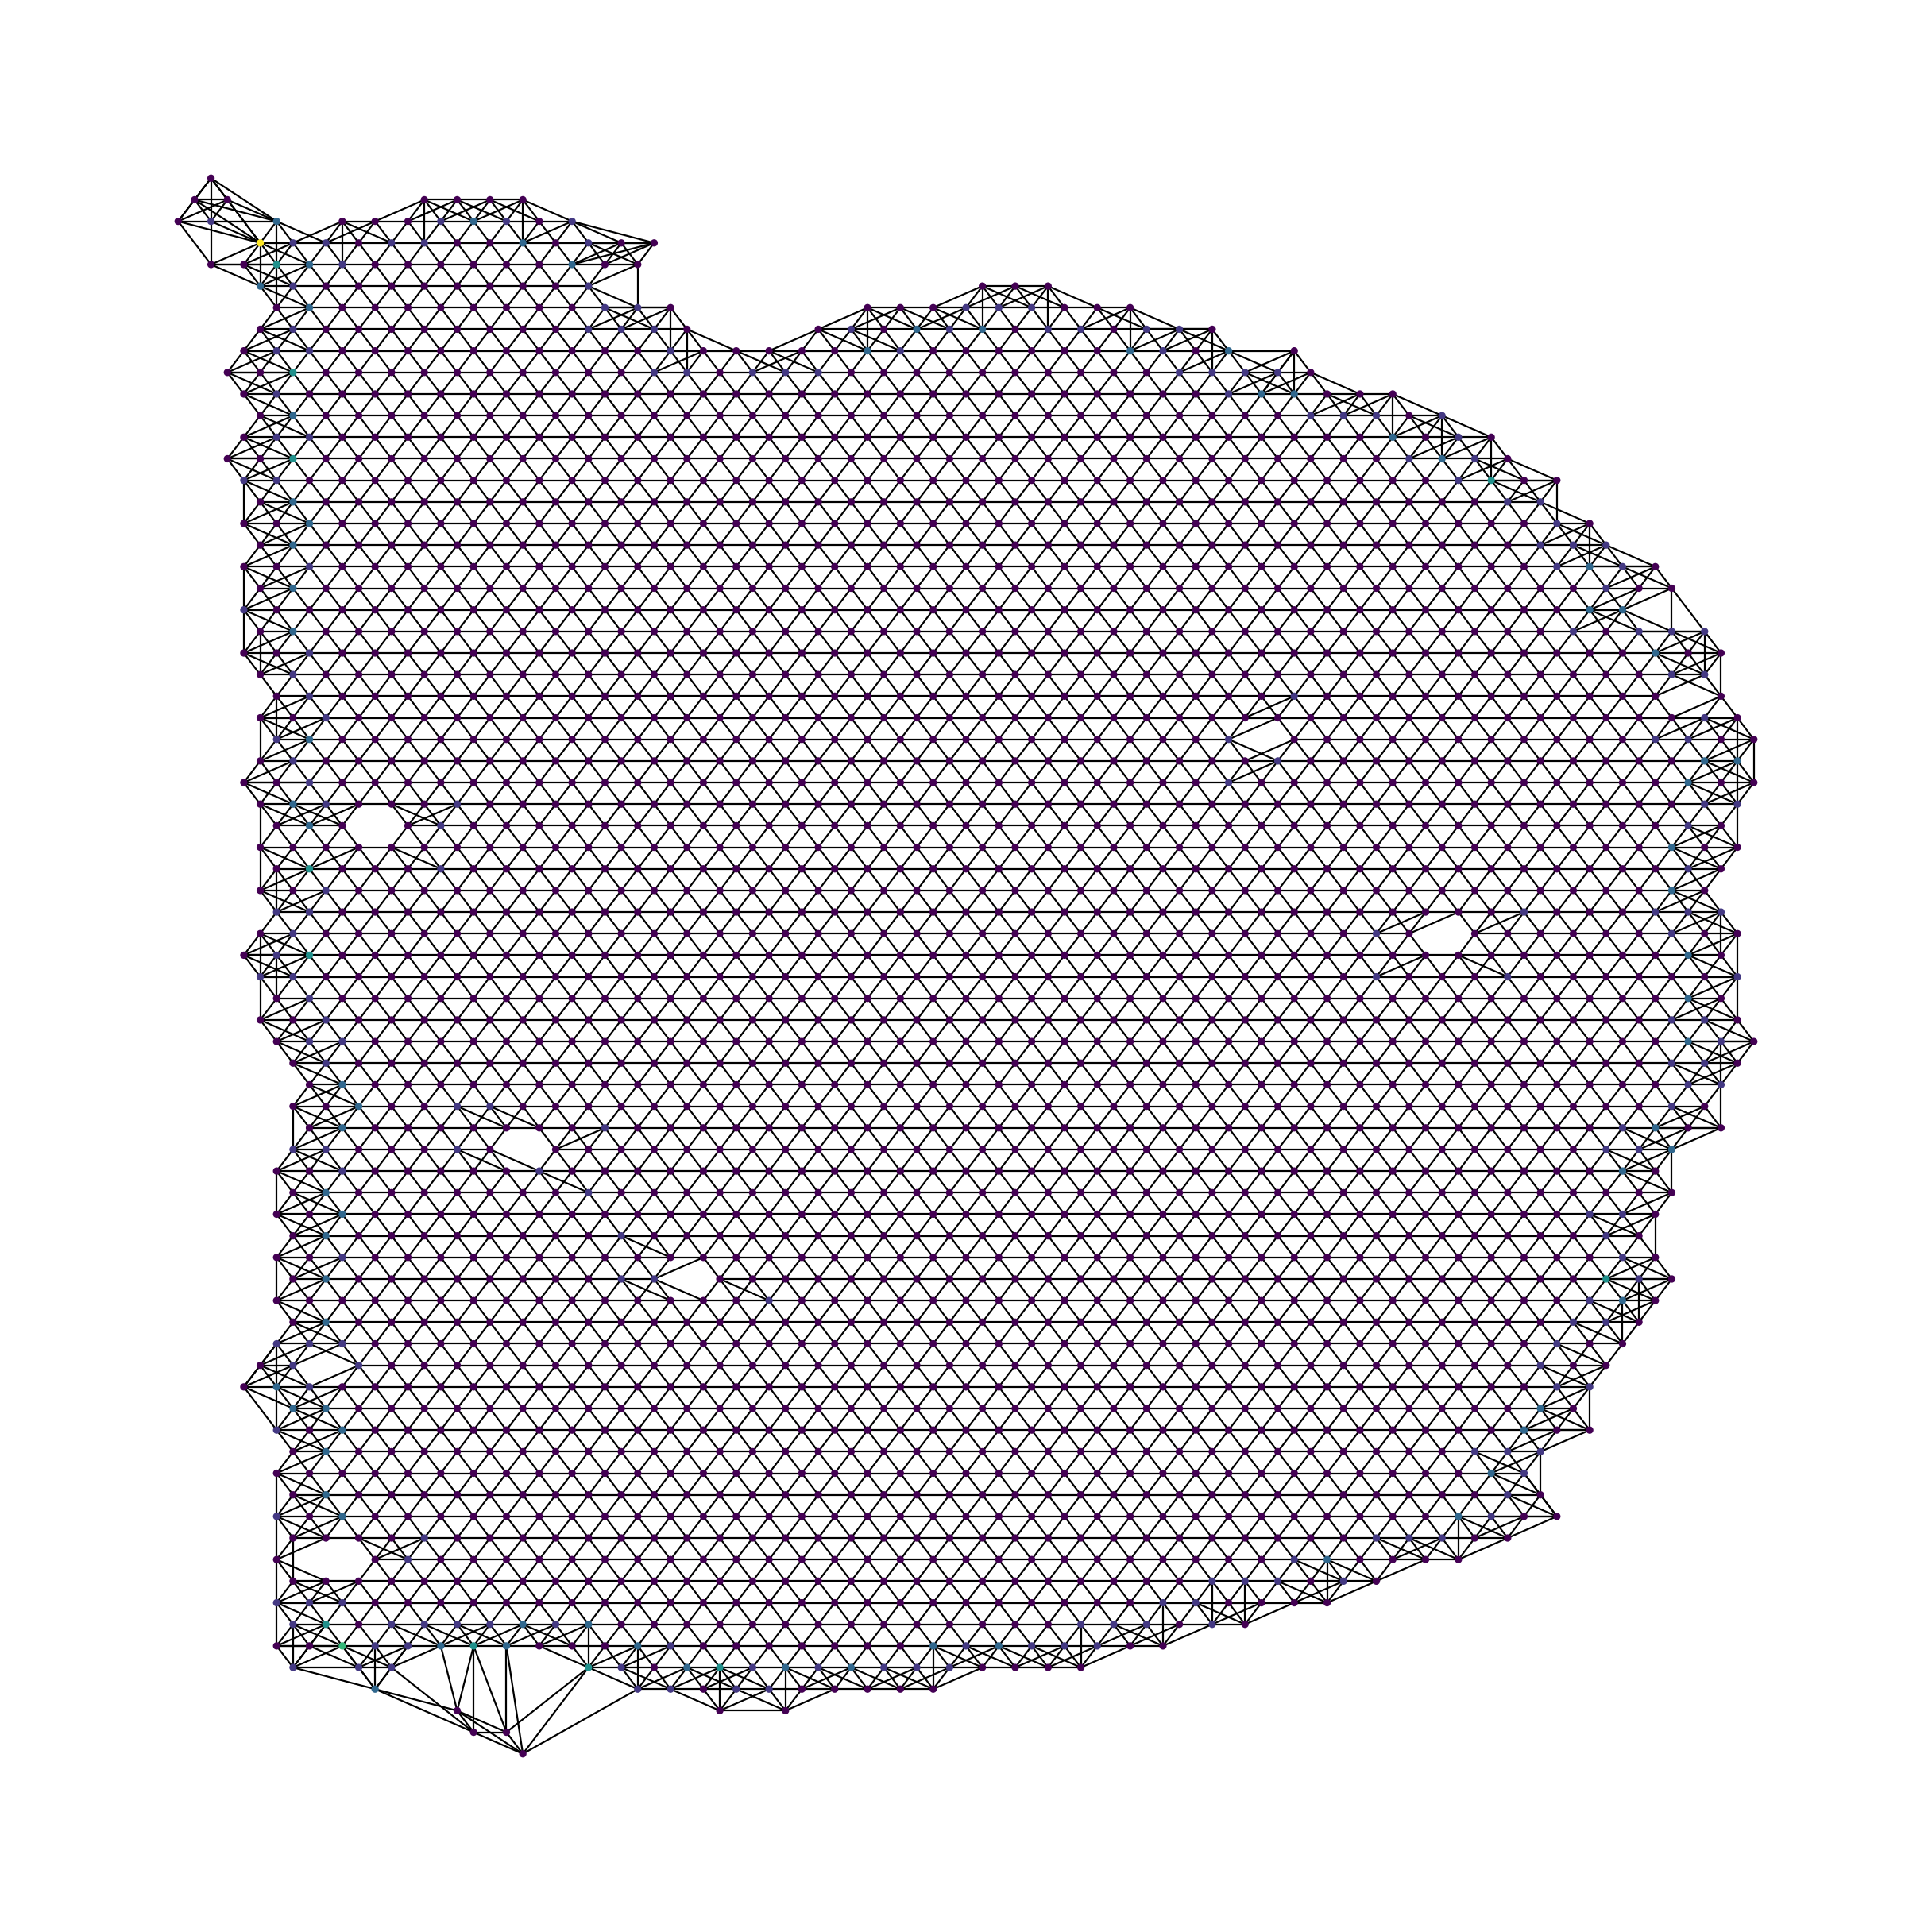

In [10]:
plt.figure(figsize=(15,15))
nx.draw(G, pos=adata.obs[["array_col", "array_row"]].values, node_color=dict(G.degree).values(), node_size=10)

In [11]:
alpha = 0.2

joint_graph = (1 - alpha) * nn_graph_genes + alpha * nn_graph_space
sc.tl.leiden(adata, adjacency=joint_graph, key_added="squidpy_domains")

/tmp/1439146.tinyfat/ipykernel_643165/3989745165.py:4: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, adjacency=joint_graph, key_added="squidpy_domains")


running Leiden clustering
    finished: found 15 clusters and added
    'squidpy_domains', the cluster labels (adata.obs, categorical) (0:00:00)


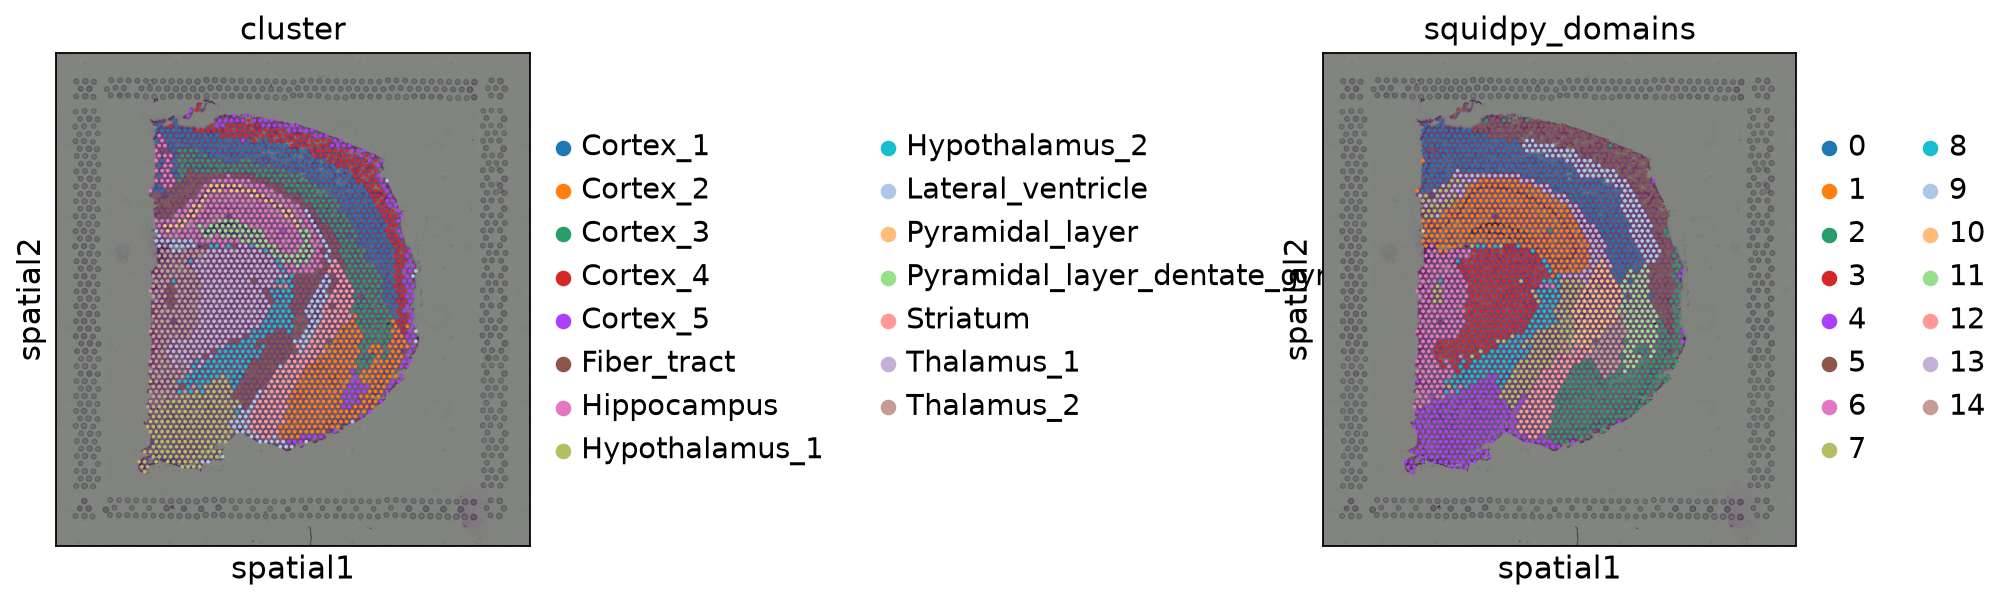

In [12]:
sq.pl.spatial_scatter(adata, color=["cluster", "squidpy_domains"], wspace=0.9)

<Axes: xlabel='squidpy_domains', ylabel='cluster'>

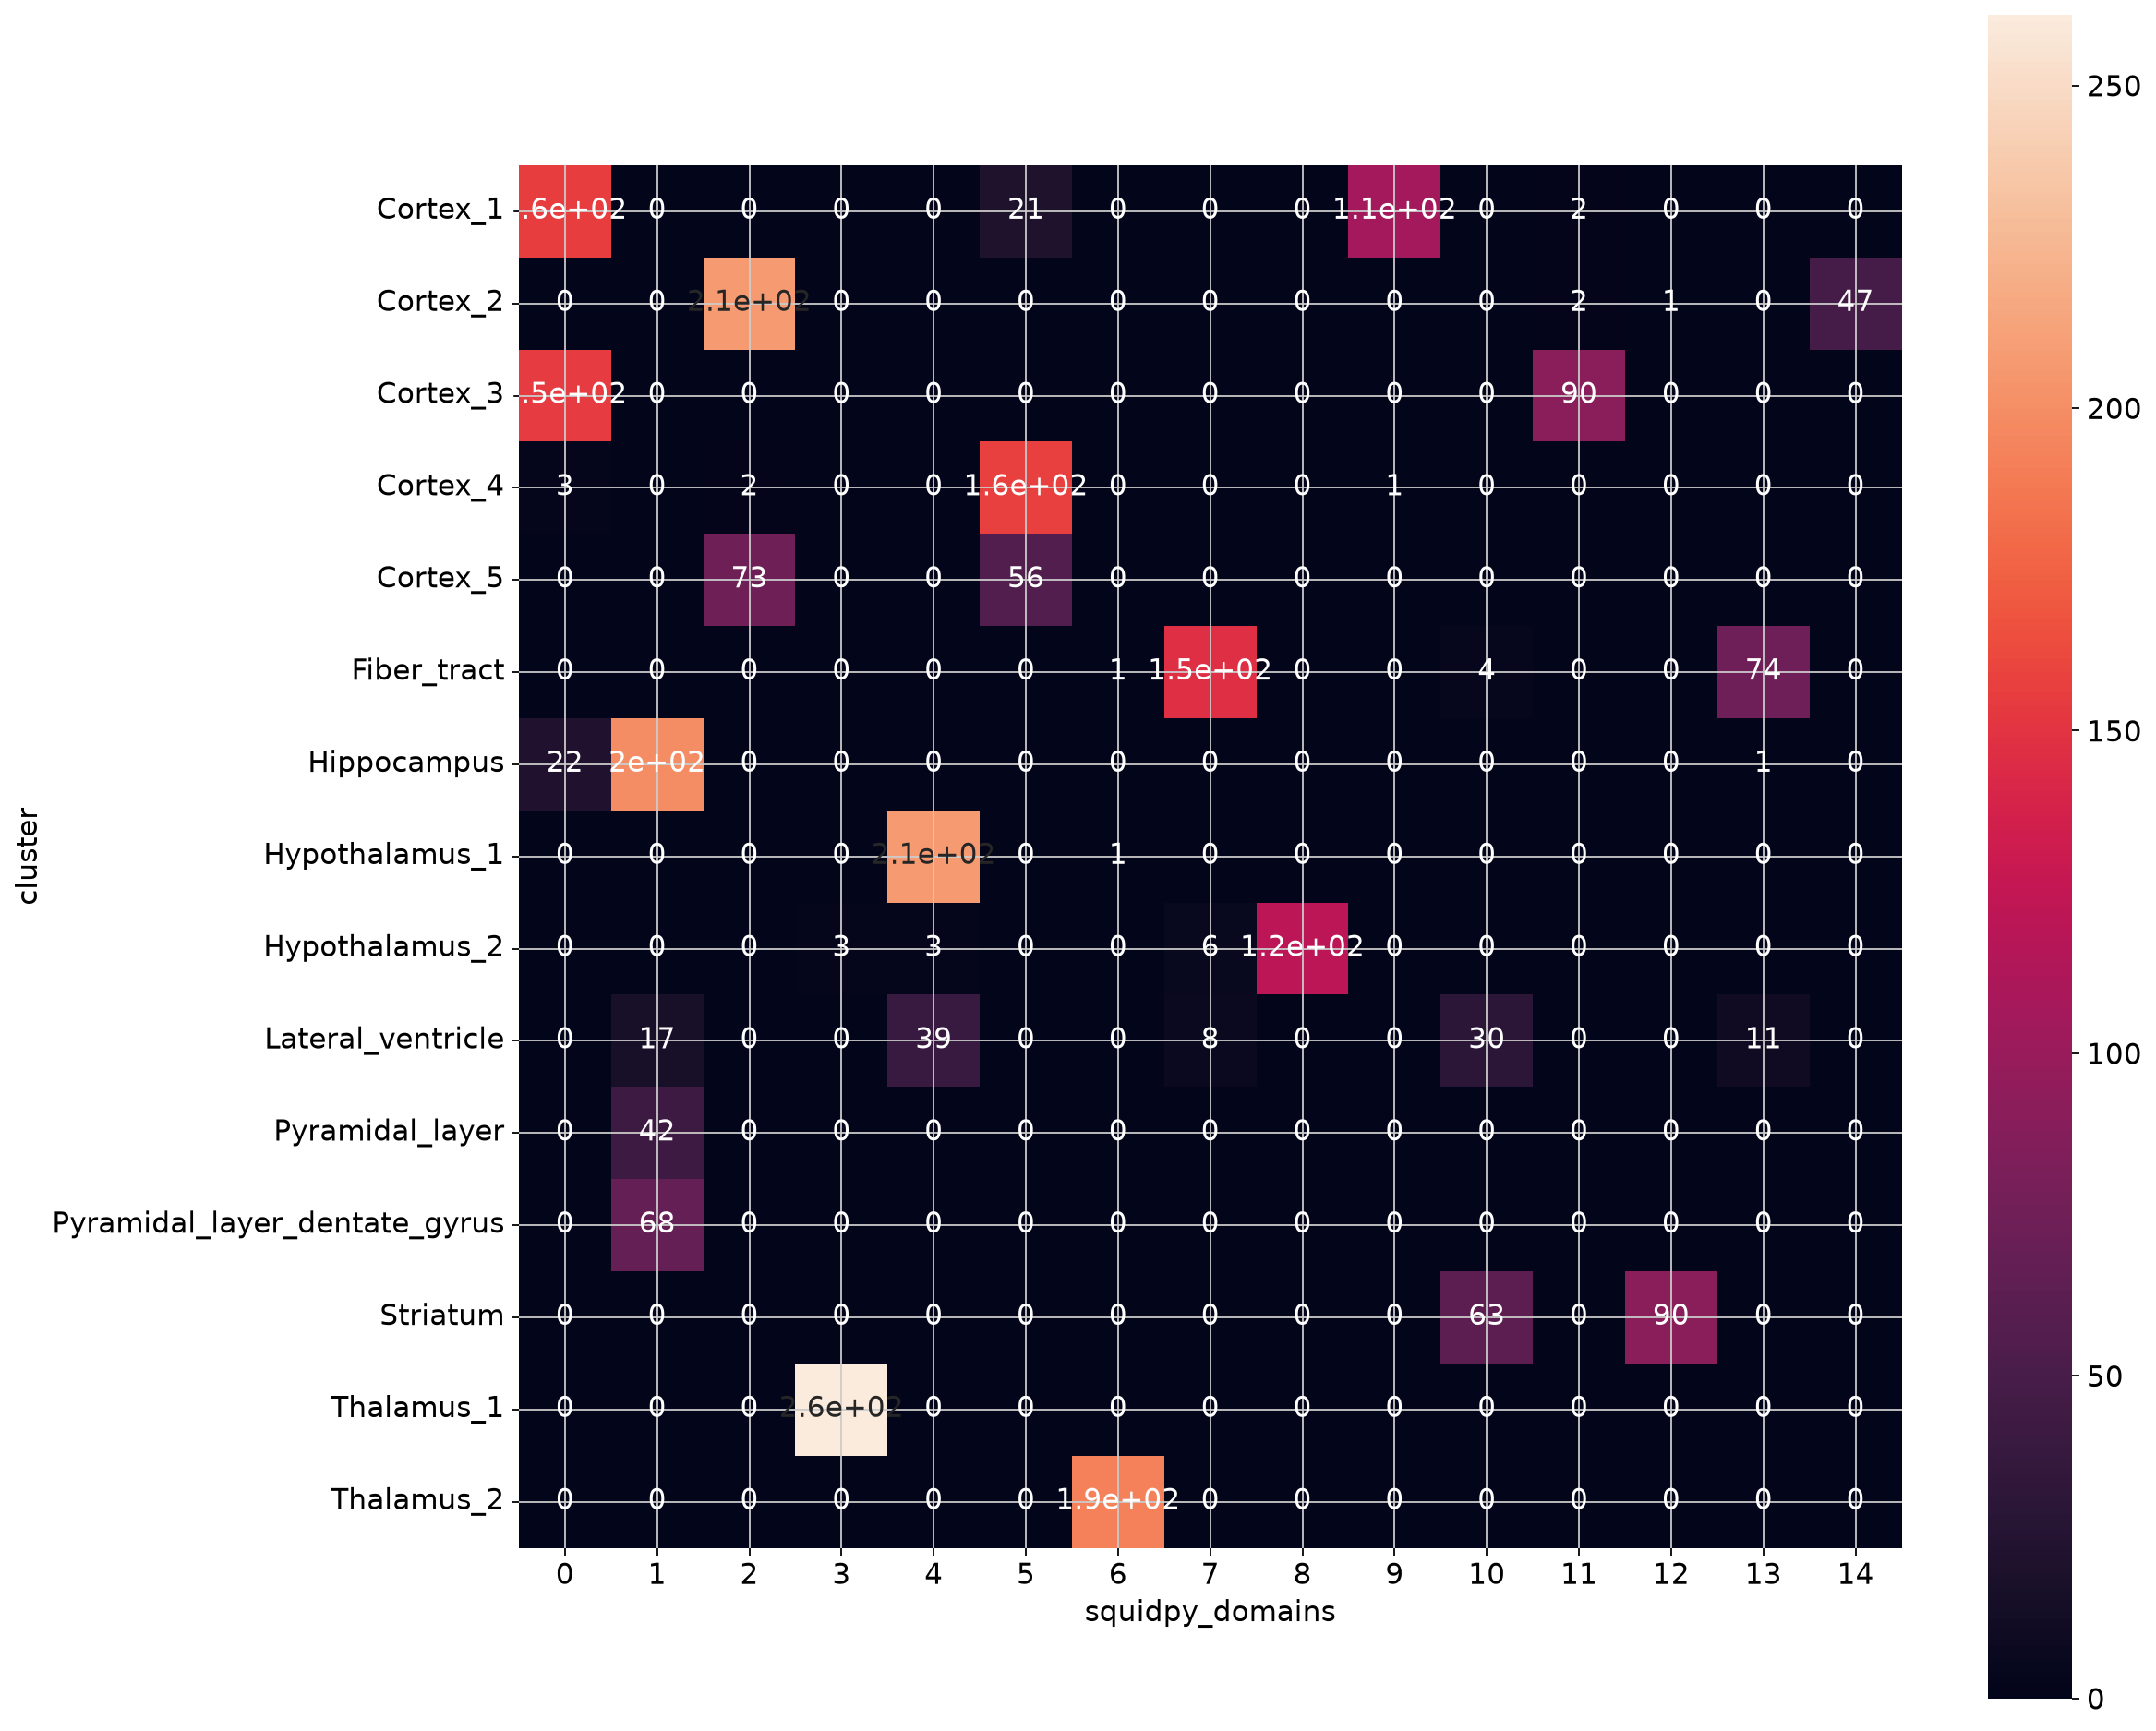

In [34]:
plt.figure(figsize=(15,15))
sns.heatmap(adata.obs[["cluster", "squidpy_domains"]].value_counts().reset_index().pivot(index="cluster", columns="squidpy_domains", values="count").fillna(0).astype(int), square=True, annot=True)